
# CNN vs ViT on Chest X‑ray (Recall‑first) — with SAM, DropPath, and Google ViT .npz

**Goal.** Recreate your pipeline (same data split behavior as your CNN & ViT notebooks) and add a ViT training recipe aligned with *When Vision Transformers Outperform ResNets Without Pre‑training or Strong Data Augmentations* (ICLR 2022). We include:

- Data split identical to your setup (uses `train/` + stratified 20% for `val/` if the native `val/` folder is tiny as in Kaggle chest_xray).
- Custom CNN (from scratch) and a pretrained **ResNet‑18**.
- Custom **ViT** (from scratch) **+ SAM optimizer** and **DropPath** (stochastic depth).
- **Pretrained ViT‑B/16**: loads Google JAX `.npz` checkpoint offline (if present).
- **Recall‑first evaluation**: pick a threshold on **val** that hits a target recall, then evaluate on **test** at `0.5` and at the calibrated threshold.
- Curves, confusion matrices, ROC / PR plots, and a final comparison table.

> **Note**: You only need to set `DATA_DIR` (and optionally `NPZ_PATH`). The notebook will handle the rest.


In [2]:

# %% [code] {"id":"setup"}
import os, math, time, random, json, copy, sys, itertools
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, datasets, models

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve,
                             precision_recall_curve, average_precision_score)
import matplotlib.pyplot as plt

# ----------------------- Device -----------------------
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

torch.set_float32_matmul_precision('high')

# ----------------------- Config -----------------------
@dataclass
class Cfg:
    image_size: int = 224
    in_channels: int = 3
    batch_size: int = 32
    num_workers: int = 0  # set 0 for macOS MPS; bump on CUDA
    use_stratified_val: bool = True
    stratified_val_size: float = 0.20

    # CNN (scratch)
    cnn_epochs: int = 15
    cnn_lr: float = 3e-4
    cnn_wd: float = 5e-2

    # ResNet (pretrained)
    resnet_epochs: int = 10
    resnet_lr: float = 1e-4
    resnet_wd: float = 5e-2

    # ViT (scratch) — small
    patch_size: int = 16
    embed_dim: int = 256
    depth: int = 6
    num_heads: int = 8
    mlp_ratio: float = 4.0
    drop_rate: float = 0.10
    drop_path_rate: float = 0.05

    # ViT (pretrained) — B/16
    pretrained_epochs: int = 10
    pretrained_lr: float = 1e-4
    pretrained_wd: float = 5e-2

    # Training control
    patience: int = 5
    monitor: str = "va_auroc"  # or "va_f1"
    use_class_weights: bool = True
    label_smoothing: float = 0.05
    target_recall: float = 0.95  # recall-first evaluation

cfg = Cfg()

# ----------------------- Paths -----------------------
# >>>>> CHANGE ONLY THESE TWO IF NEEDED <<<<<
# Paths (run from notebooks/)
REPO_ROOT   = Path.cwd().parent
DATASET_DIR = REPO_ROOT / "Data" / "chest_xray"
WEIGHTS_DIR = Path.cwd() / "weights"
WEIGHTS_DIR.mkdir(exist_ok=True, parents=True)

print("Dataset dir:", DATASET_DIR.resolve())
print("Weights dir:", WEIGHTS_DIR.resolve())

# ----------------------- Repro -----------------------
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(123)


Dataset dir: /Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/Data/chest_xray
Weights dir: /Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/notebooks/weights


In [3]:

# %% [code] {"id":"utils"}
class AverageMeter:
    def __init__(self):
        self.sum = 0.0; self.count = 0
    def update(self, val, n=1):
        self.sum += float(val) * n; self.count += n
    @property
    def avg(self): return self.sum / max(1, self.count)

def plot_curve(tr, va, title):
    plt.figure(figsize=(6,4))
    plt.plot(tr, label="train")
    plt.plot(va, label="val")
    plt.title(title); plt.xlabel("epoch"); plt.legend(); plt.tight_layout(); plt.show()

def choose_threshold_by_min_recall(y_true, p1, min_recall=0.95):
    """
    Pick the highest-precision threshold whose recall >= min_recall on y_true.
    Returns (thr, recall_at_thr, precision_at_thr, f1_at_thr).
    """
    prec, rec, thr = precision_recall_curve(y_true, p1)
    candidates = []
    for i in range(len(thr)):
        r = rec[i]
        p = prec[i]
        t = thr[i]
        if r >= min_recall:
            f1 = 0.0 if (p + r) == 0 else 2*p*r/(p+r)
            candidates.append((t, r, p, f1))
    if not candidates:
        t = float(np.min(thr)) if len(thr) else 0.5
        yhat = (p1 >= t).astype(int)
        return t, recall_score(y_true, yhat, zero_division=0), precision_score(y_true, yhat, zero_division=0), f1_score(y_true, yhat, zero_division=0)
    candidates.sort(key=lambda x: (x[2], x[3], -x[0]), reverse=True)
    return candidates[0]

def summarize_at_threshold(y, p1, thr):
    yhat = (p1 >= thr).astype(int)
    return {
        "acc": accuracy_score(y, yhat),
        "precision": precision_score(y, yhat, zero_division=0),
        "recall": recall_score(y, yhat, zero_division=0),
        "f1": f1_score(y, yhat, zero_division=0),
        "auroc": roc_auc_score(y, p1),
        "thr": float(thr)
    }

def diag_plots(model_name, probs, y_true, thr, auroc=None, class_names=("NORMAL","PNEUMONIA")):
    y_hat = (probs[:,1] >= thr).astype(int)
    cm = confusion_matrix(y_true, y_hat)
    # Confusion Matrix
    plt.figure(figsize=(4,4))
    plt.imshow(cm, interpolation='nearest')
    plt.title(f"{model_name} — Confusion (thr={thr:.3f})")
    plt.colorbar(); ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45); plt.yticks(ticks, class_names)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout(); plt.show()

    # ROC
    fpr, tpr, _ = roc_curve(y_true, probs[:,1])
    if auroc is None:
        auroc = roc_auc_score(y_true, probs[:,1])
    plt.figure(figsize=(5,4)); plt.plot(fpr, tpr, lw=2); plt.plot([0,1],[0,1],'--')
    plt.title(f"{model_name} — ROC (AUROC={auroc:.4f})"); plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.tight_layout(); plt.show()

    # PR
    prec, rec, _ = precision_recall_curve(y_true, probs[:,1])
    ap = average_precision_score(y_true, probs[:,1])
    plt.figure(figsize=(5,4)); plt.plot(rec, prec, lw=2)
    plt.title(f"{model_name} — PR (AP={ap:.4f})"); plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.tight_layout(); plt.show()


In [5]:

# %% [code] {"id":"data"}
# Transforms: follow simple Inception-style (random crop + horizontal flip), be gentle for X-rays.
train_tf = transforms.Compose([
    transforms.Resize((cfg.image_size, cfg.image_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
])

test_tf = transforms.Compose([
    transforms.Resize((cfg.image_size, cfg.image_size)),
    transforms.ToTensor(),
])

# Load folders. Kaggle chest_xray has train/val/test; but val has 16 images -> we'll stratify from train.
train_dir = DATASET_DIR / "train"
val_dir   = DATASET_DIR/ "val"
test_dir  = DATASET_DIR / "test"

# Base datasets
base_train = datasets.ImageFolder(train_dir, transform=train_tf)
base_val   = datasets.ImageFolder(val_dir,   transform=test_tf) if val_dir.exists() else None
base_test  = datasets.ImageFolder(test_dir,  transform=test_tf)

class_names = base_test.classes
print("Classes:", class_names)

# Decide whether to re-split validation
make_split = False
if base_val is not None and len(base_val) < 100 and cfg.use_stratified_val:
    make_split = True
elif base_val is None and cfg.use_stratified_val:
    make_split = True

if make_split:
    # stratified split from 'train'
    from sklearn.model_selection import StratifiedShuffleSplit
    y = np.array([y for _, y in base_train.samples])
    sss = StratifiedShuffleSplit(n_splits=1, test_size=cfg.stratified_val_size, random_state=123)
    idx_train, idx_val = next(sss.split(np.zeros(len(y)), y))
    train_ds = Subset(datasets.ImageFolder(train_dir, transform=train_tf), idx_train)
    val_ds   = Subset(datasets.ImageFolder(train_dir, transform=test_tf), idx_val)
else:
    train_ds = base_train
    val_ds   = base_val

test_ds = base_test

# Counts (for class weights)
train_targets = []
if isinstance(train_ds, Subset):
    train_targets = [base_train.samples[i][1] for i in train_ds.indices]
else:
    train_targets = [y for _, y in train_ds.samples]
train_counts = np.bincount(np.array(train_targets), minlength=len(class_names))

# Loaders
pin = (DEVICE.type == "cuda")
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, pin_memory=pin)
val_loader   = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=pin)
test_loader  = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=pin)

print(len(train_ds), len(val_ds), len(test_ds))
print("Train counts:", train_counts)


Classes: ['NORMAL', 'PNEUMONIA']
4172 1044 624
Train counts: [1073 3099]


In [6]:

# %% [code] {"id":"models_cnn"}
class SimpleCNN(nn.Module):
    def __init__(self, in_ch=3, num_classes=2):
        super().__init__()
        def block(c_in, c_out):
            return nn.Sequential(
                nn.Conv2d(c_in, c_out, 3, padding=1, bias=False),
                nn.BatchNorm2d(c_out),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2)
            )
        self.features = nn.Sequential(
            block(in_ch, 32),    # 224 -> 112
            block(32, 64),       # 112 -> 56
            block(64, 128),      # 56 -> 28
            block(128, 256),     # 28 -> 14
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.head(x)
        return x

def build_resnet18(num_classes=2, pretrained=True):
    try:
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        m = models.resnet18(weights=weights)
    except Exception:
        m = models.resnet18(pretrained=pretrained)  # for older torchvision
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m


In [7]:

# %% [code] {"id":"vit_core"}
class DropPath(nn.Module):
    """Stochastic Depth per sample (when applied in residual blocks)."""
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = float(drop_prob)

    def forward(self, x):
        if self.drop_prob == 0.0 or not self.training:
            return x
        keep_prob = 1.0 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
        random_tensor.floor_()  # binarize
        return x.div(keep_prob) * random_tensor

class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.grid_size = img_size // patch_size
        self.num_patches = self.grid_size * self.grid_size
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)               # [B, D, H/P, W/P]
        x = x.flatten(2).transpose(1,2)  # [B, N, D]
        return x

class MLP(nn.Module):
    def __init__(self, dim, mlp_ratio=4.0, drop=0.0):
        super().__init__()
        hidden = int(dim * mlp_ratio)
        self.fc1 = nn.Linear(dim, hidden)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden, dim)
        self.drop = nn.Dropout(drop)
    def forward(self, x):
        x = self.fc1(x); x = self.act(x); x = self.drop(x)
        x = self.fc2(x); x = self.drop(x); return x

class Attention(nn.Module):
    def __init__(self, dim, num_heads=8, qkv_bias=True, attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)
    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2,0,3,1,4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1,2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

class Block(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0, drop=0.0, drop_path=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim, eps=1e-6)
        self.attn = Attention(dim, num_heads=num_heads)
        self.drop_path1 = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()
        self.norm2 = nn.LayerNorm(dim, eps=1e-6)
        self.mlp = MLP(dim, mlp_ratio=mlp_ratio, drop=drop)
        self.drop_path2 = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x):
        x = x + self.drop_path1(self.attn(self.norm1(x)))
        x = x + self.drop_path2(self.mlp(self.norm2(x)))
        return x

class VisionTransformer(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, num_classes=2,
                 embed_dim=768, depth=12, num_heads=12, mlp_ratio=4.0, drop_rate=0.0):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        self.num_tokens = 1
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_tokens + self.patch_embed.num_patches, embed_dim))
        self.pos_drop = nn.Dropout(p=drop_rate)
        # stochastic depth decay
        dpr = torch.linspace(0, cfg.drop_path_rate, steps=depth).tolist()
        self.blocks = nn.ModuleList([
            Block(embed_dim, num_heads, mlp_ratio, drop=drop_rate, drop_path=dpr[i])
            for i in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim, eps=1e-6)
        self.head = nn.Linear(embed_dim, num_classes)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.pos_drop(x)
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        x = self.head(x[:, 0])
        return x


In [26]:
# Robust JAX->PyTorch ViT-B/16 loader with flexible key names
import numpy as np, torch
import torch.nn.functional as F
from pathlib import Path

@torch.no_grad()
def _get_any(w, keys):
    """Return the first matching key in the npz 'w'."""
    for k in keys:
        if k in w:
            return w[k]
    raise KeyError("None of keys found:\n  " + "\n  ".join(keys))

@torch.no_grad()
def load_vit_npz_flexible(model, npz_path: str | Path):
    """
    Load Google/Flax ViT-B/16 (.npz) into our PyTorch ViT.
    Handles key variants:
      - Attention: MultiHeadDotProductAttention_1 / _0 / (no suffix)
      - MLP:       Mlp / MlpBlock_3 / MlpBlock_4
    Keeps the PyTorch classifier head (num_classes=2).
    """
    w = np.load(str(npz_path))
    D = model.head.in_features  # 768 for B/16

    def n2t(x): return torch.from_numpy(x).float()

    # 1) Patch embedding: JAX [P,P,in,D] -> torch conv [D,in,P,P]
    model.patch_embed.proj.weight.copy_(n2t(w['embedding/kernel']).permute(3,2,0,1))
    model.patch_embed.proj.bias.copy_(  n2t(w['embedding/bias']))

    # 2) [CLS] + positional embeddings (interpolate if patch grid differs)
    model.cls_token.copy_(n2t(w['cls']))
    posemb = w['Transformer/posembed_input/pos_embedding']  # [1,1+N,D]
    if posemb.shape[1] != model.pos_embed.shape[1]:
        cls_pos = posemb[:, :1]
        grid_pos = posemb[:, 1:]  # [1,N0,D]
        gs_old  = int(np.sqrt(grid_pos.shape[1]))
        grid_pos = grid_pos.reshape(1, gs_old, gs_old, D).transpose(0,3,1,2)  # 1,D,gh,gw
        H = W    = int((model.patch_embed.num_patches) ** 0.5)
        grid_pos = F.interpolate(n2t(grid_pos), size=(H, W), mode='bicubic', align_corners=False)
        grid_pos = grid_pos.permute(0,2,3,1).reshape(1, H*W, D).numpy()
        posemb   = np.concatenate([cls_pos, grid_pos], axis=1)
    model.pos_embed.copy_(n2t(posemb))

    # Helpers to reshape DenseGeneral -> Linear
    def flatten_qkv(W, b):
        # common JAX shapes: W [D, H, Hd] or [D, D]; b [H, Hd] or [D]
        if W.ndim == 3:
            W = W.reshape(W.shape[0], -1)   # -> [D, D]
        b = b.reshape(-1)                   # -> [D]
        return W, b

    def flatten_out(Wo):
        # common JAX shape: Wo [H, Hd, D] -> [D_out, D_in] = [D, D] for torch
        if Wo.ndim == 3:
            Wo = Wo.reshape(-1, Wo.shape[-1])  # [H*Hd, D] == [D_in, D_out]
        elif Wo.ndim != 2:
            raise ValueError(f"Unexpected out-kernel ndim: {Wo.ndim}")
        return Wo.T  # [D_out, D_in]

    # Prefix candidates per block
    def attn_prefixes(i):
        base = f'Transformer/encoderblock_{i}/MultiHeadDotProductAttention'
        return [f'{base}_1', f'{base}_0', f'{base}']  # try _1, then _0, then no suffix

    def mlp_prefixes(i):
        base = f'Transformer/encoderblock_{i}'
        return [f'{base}/Mlp', f'{base}/MlpBlock_3', f'{base}/MlpBlock_4']

    # 3) Encoder blocks
    for i, blk in enumerate(model.blocks):
        # LayerNorms
        blk.norm1.weight.copy_(n2t(_get_any(w, [f'Transformer/encoderblock_{i}/LayerNorm_0/scale'])))
        blk.norm1.bias.copy_(  n2t(_get_any(w, [f'Transformer/encoderblock_{i}/LayerNorm_0/bias'])))
        blk.norm2.weight.copy_(n2t(_get_any(w, [f'Transformer/encoderblock_{i}/LayerNorm_2/scale'])))
        blk.norm2.bias.copy_(  n2t(_get_any(w, [f'Transformer/encoderblock_{i}/LayerNorm_2/bias'])))

        # Attention q/k/v
        ap = attn_prefixes(i)
        Wq = _get_any(w, [f'{p}/query/kernel' for p in ap]);  bq = _get_any(w, [f'{p}/query/bias' for p in ap])
        Wk = _get_any(w, [f'{p}/key/kernel'   for p in ap]);  bk = _get_any(w, [f'{p}/key/bias'  for p in ap])
        Wv = _get_any(w, [f'{p}/value/kernel' for p in ap]);  bv = _get_any(w, [f'{p}/value/bias' for p in ap])
        Wq, bq = flatten_qkv(Wq, bq);  Wk, bk = flatten_qkv(Wk, bk);  Wv, bv = flatten_qkv(Wv, bv)
        Wqkv = np.concatenate([Wq, Wk, Wv], axis=1).T  # [3D, D]
        bqkv = np.concatenate([bq, bk, bv], axis=0)    # [3D]
        blk.attn.qkv.weight.copy_(n2t(Wqkv))
        blk.attn.qkv.bias.copy_(  n2t(bqkv))

        # Attention out
        Wo = _get_any(w, [f'{p}/out/kernel' for p in ap])
        bo = _get_any(w, [f'{p}/out/bias'   for p in ap])
        blk.attn.proj.weight.copy_(n2t(flatten_out(Wo)))
        blk.attn.proj.bias.copy_(  n2t(bo))

        # MLP (supports Mlp, MlpBlock_3, MlpBlock_4)
        mp  = mlp_prefixes(i)
        Wm0 = _get_any(w, [f'{p}/Dense_0/kernel' for p in mp]);  bm0 = _get_any(w, [f'{p}/Dense_0/bias' for p in mp])
        Wm1 = _get_any(w, [f'{p}/Dense_1/kernel' for p in mp]);  bm1 = _get_any(w, [f'{p}/Dense_1/bias' for p in mp])
        blk.mlp.fc1.weight.copy_(n2t(Wm0).T); blk.mlp.fc1.bias.copy_(n2t(bm0))
        blk.mlp.fc2.weight.copy_(n2t(Wm1).T); blk.mlp.fc2.bias.copy_(n2t(bm1))

    # 4) Final encoder LN
    model.norm.weight.copy_(n2t(w['Transformer/encoder_norm/scale']))
    model.norm.bias.copy_(  n2t(w['Transformer/encoder_norm/bias']))

    return model


In [9]:

# %% [code] {"id":"sam"}
class SAM(torch.optim.Optimizer):
    """Sharpness-Aware Minimization optimizer (Foret et al., 2021).
    Wrap a base optimizer (e.g., AdamW). Use:
        sam = SAM(model.parameters(), torch.optim.AdamW, lr=..., weight_decay=...)
        for input, target in ...:
            # first forward-backward
            loss = loss_fn(model(input), target); loss.backward(); sam.first_step()
            # second forward-backward at perturbed weights
            loss_fn(model(input), target).backward(); sam.second_step()
    """
    def __init__(self, params, base_optimizer, rho=0.2, adaptive=False, **kwargs):
        assert rho >= 0.0, "rho must be non-negative"
        defaults = dict(rho=rho, adaptive=adaptive, **kwargs)
        super().__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups = self.base_optimizer.param_groups

    @torch.no_grad()
    def first_step(self, zero_grad=True):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group["rho"] / (grad_norm + 1e-12)
            for p in group["params"]:
                if p.grad is None: continue
                e_w = (torch.pow(p, 2) if group["adaptive"] else 1.0) * p.grad * scale
                p.add_(e_w)
                self.state[p]["e_w"] = e_w
        if zero_grad:
            self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=True):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None: continue
                p.sub_(self.state[p]["e_w"])
        self.base_optimizer.step()
        if zero_grad:
            self.zero_grad()

    def step(self, closure=None):
        raise RuntimeError("SAM doesn't support step() directly. Use first_step() / second_step().")

    def zero_grad(self):
        self.base_optimizer.zero_grad()

    def _grad_norm(self):
        device = self.param_groups[0]["params"][0].device
        norms = []
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None: continue
                g = p.grad
                if group["adaptive"]:
                    g = torch.abs(p) * g
                norms.append(torch.norm(g, p=2))
        if not norms:
            return torch.tensor(0.0, device=device)
        return torch.norm(torch.stack(norms), p=2)


In [10]:

# %% [code] {"id":"train_eval"}
def build_loss(class_weights=None, label_smoothing=0.0):
    if class_weights is not None:
        w = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
    else:
        w = None
    return nn.CrossEntropyLoss(weight=w, label_smoothing=label_smoothing).to(DEVICE)

def train_model(model, train_loader, val_loader, device, *, epochs, base_lr, weight_decay,
                class_weights=None, monitor="va_auroc", patience=5, tag="model", use_sam=False, sam_rho=0.2):
    loss_fn = build_loss(class_weights, cfg.label_smoothing)
    if use_sam:
        optimizer = SAM(model.parameters(), torch.optim.AdamW, lr=base_lr, weight_decay=weight_decay, rho=sam_rho)
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=weight_decay)
    best_metric = -1.0
    best_state = copy.deepcopy(model.state_dict())
    no_improve = 0
    hist = {"tr_loss":[], "va_loss":[], "va_acc":[], "va_f1":[], "va_auroc":[]}
    start = time.time()

    for epoch in range(1, epochs+1):
        model.train()
        tr_loss = AverageMeter()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            if use_sam:
                # first forward-backward
                logits = model(xb)
                loss = loss_fn(logits, yb)
                loss.backward()
                optimizer.first_step()

                # second forward-backward
                logits2 = model(xb)
                loss2 = loss_fn(logits2, yb)
                loss2.backward()
                optimizer.second_step()
                tr_loss.update(loss.item(), xb.size(0))
            else:
                optimizer.zero_grad(set_to_none=True)
                logits = model(xb)
                loss = loss_fn(logits, yb)
                loss.backward()
                optimizer.step()
                tr_loss.update(loss.item(), xb.size(0))

        # evaluate
        model.eval()
        va_loss = AverageMeter()
        ys = []; ps = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = loss_fn(logits, yb)
                va_loss.update(loss.item(), xb.size(0))
                prob = torch.softmax(logits, dim=1).cpu().numpy()
                ys.append(yb.cpu().numpy()); ps.append(prob)
        y = np.concatenate(ys); p = np.concatenate(ps)
        yhat = (p[:,1] >= 0.5).astype(int)
        va_acc = accuracy_score(y, yhat)
        va_f1 = f1_score(y, yhat, zero_division=0)
        try:
            va_auroc = roc_auc_score(y, p[:,1])
        except Exception:
            va_auroc = float("nan")

        hist["tr_loss"].append(tr_loss.avg)
        hist["va_loss"].append(va_loss.avg)
        hist["va_acc"].append(va_acc)
        hist["va_f1"].append(va_f1)
        hist["va_auroc"].append(va_auroc)

        metric = va_auroc if monitor=="va_auroc" else va_f1
        improved = (metric > best_metric) if not math.isnan(metric) else False
        if improved:
            best_metric = metric; best_state = copy.deepcopy(model.state_dict()); no_improve = 0
        else:
            no_improve += 1

        print(f"[{tag}] epoch {epoch:02d}/{epochs}  tr_loss={tr_loss.avg:.4f}  val_loss={va_loss.avg:.4f}  "
              f"val_acc={va_acc:.4f}  val_f1={va_f1:.4f}  val_auroc={va_auroc:.4f}  (no_improve={no_improve})")

        if no_improve >= patience:
            print(f"[{tag}] early stopping at epoch {epoch}.")
            break

    model.load_state_dict(best_state)
    elapsed = time.time() - start
    return model, hist, elapsed

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    ys = []; ps = []; logits_all = []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        prob = torch.softmax(logits, dim=1).cpu().numpy()
        ys.append(yb.numpy())
        ps.append(prob)
        logits_all.append(logits.cpu().numpy())
    y = np.concatenate(ys); p = np.concatenate(ps); log = np.concatenate(logits_all)
    return {"targets": y, "probs": p, "logits": log, "auroc": roc_auc_score(y, p[:,1])}


/var/folders/78/hsq9362565qck24p_twrvs0cx236x4/T/ipykernel_59884/2400442194.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  w = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)


[cnn_scratch] epoch 01/15  tr_loss=0.3856  val_loss=0.8805  val_acc=0.5852  val_f1=0.6130  val_auroc=0.9439  (no_improve=0)
[cnn_scratch] epoch 02/15  tr_loss=0.3274  val_loss=0.7485  val_acc=0.8113  val_f1=0.8872  val_auroc=0.9832  (no_improve=0)
[cnn_scratch] epoch 03/15  tr_loss=0.2951  val_loss=0.2826  val_acc=0.9387  val_f1=0.9577  val_auroc=0.9863  (no_improve=0)
[cnn_scratch] epoch 04/15  tr_loss=0.2797  val_loss=0.2754  val_acc=0.9349  val_f1=0.9546  val_auroc=0.9867  (no_improve=0)
[cnn_scratch] epoch 05/15  tr_loss=0.2796  val_loss=0.2811  val_acc=0.9569  val_f1=0.9706  val_auroc=0.9902  (no_improve=0)
[cnn_scratch] epoch 06/15  tr_loss=0.2587  val_loss=0.3158  val_acc=0.8793  val_f1=0.9123  val_auroc=0.9884  (no_improve=1)
[cnn_scratch] epoch 07/15  tr_loss=0.2513  val_loss=0.3965  val_acc=0.8132  val_f1=0.8567  val_auroc=0.9915  (no_improve=0)
[cnn_scratch] epoch 08/15  tr_loss=0.2536  val_loss=0.2758  val_acc=0.9703  val_f1=0.9801  val_auroc=0.9923  (no_improve=0)
[cnn_scr

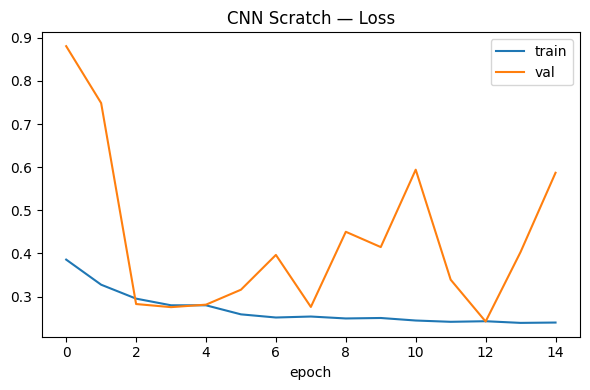

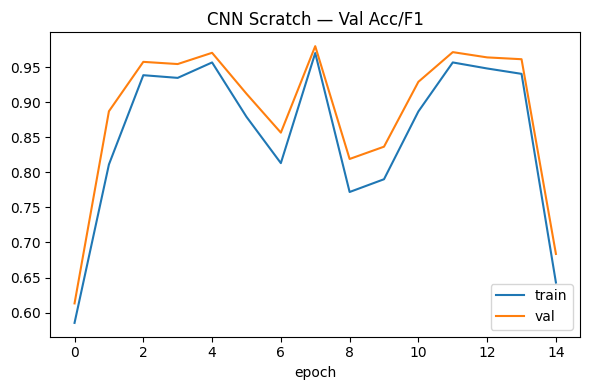

[CNN Scratch] chosen thr on VAL: 0.365 (VAL recall=0.961, precision=0.992)
[CNN Scratch @0.5] {'acc': 0.8734, 'precision': 0.8575, 'recall': 0.9564, 'f1': 0.9042, 'auroc': 0.9207, 'thr': 0.5}
[CNN Scratch @Rec] {'acc': 0.8462, 'precision': 0.8088, 'recall': 0.9872, 'f1': 0.8891, 'auroc': 0.9207, 'thr': 0.3648}


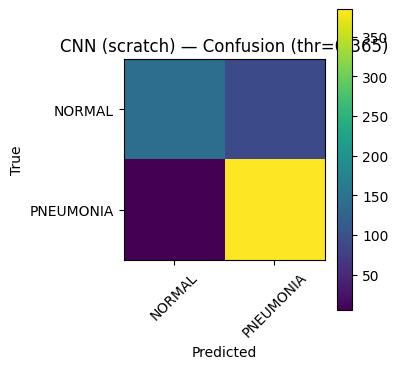

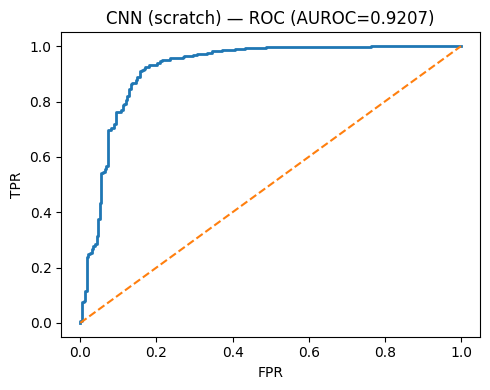

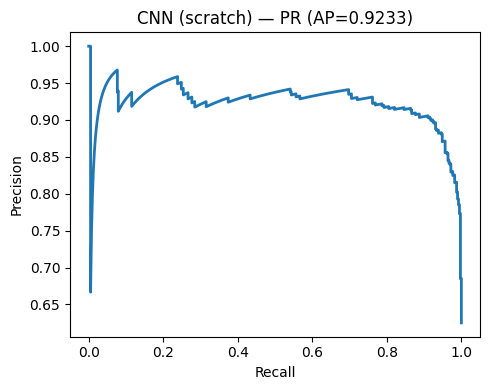

In [11]:

# %% [code] {"id":"exp_cnn_scratch"}
# ===== EXPERIMENT A: CNN (from scratch) =====
cnn = SimpleCNN(in_ch=cfg.in_channels, num_classes=2).to(DEVICE)

# Class weights to mitigate imbalance
cw = None
if cfg.use_class_weights:
    arr = np.array(train_counts, dtype=float)
    cw_vals = arr.sum() / (len(arr) * (arr + 1e-9))
    cw = torch.tensor(cw_vals, dtype=torch.float32)

cnn, hist_cnn, time_cnn = train_model(
    cnn, train_loader, val_loader, DEVICE,
    epochs=cfg.cnn_epochs, base_lr=cfg.cnn_lr, weight_decay=cfg.cnn_wd,
    class_weights=cw, monitor=cfg.monitor, patience=cfg.patience, tag="cnn_scratch"
)

plot_curve(hist_cnn["tr_loss"], hist_cnn["va_loss"], "CNN Scratch — Loss")
plot_curve(hist_cnn["va_acc"],  hist_cnn["va_f1"],  "CNN Scratch — Val Acc/F1")

# Recall-first evaluation
val_eval_c = evaluate(cnn, val_loader, DEVICE)
thr_c, rec_c, prec_c, f1c = choose_threshold_by_min_recall(val_eval_c["targets"], val_eval_c["probs"][:,1], cfg.target_recall)
print(f"[CNN Scratch] chosen thr on VAL: {thr_c:.3f} (VAL recall={rec_c:.3f}, precision={prec_c:.3f})")

test_eval_c = evaluate(cnn, test_loader, DEVICE)
p1_test = test_eval_c["probs"][:,1]; y_test = test_eval_c["targets"]
summary_c_05   = summarize_at_threshold(y_test, p1_test, 0.5)
summary_c_reca = summarize_at_threshold(y_test, p1_test, thr_c)
print("[CNN Scratch @0.5]", {k: round(v,4) for k,v in summary_c_05.items()})
print("[CNN Scratch @Rec]", {k: round(v,4) for k,v in summary_c_reca.items()})

diag_plots("CNN (scratch)", test_eval_c["probs"], y_test, thr_c, auroc=test_eval_c.get("auroc"))

cnn_results = {
    "summary@0.5": summary_c_05, "summary@recall": summary_c_reca,
    "threshold": float(thr_c), "time_sec": time_cnn,
    "params": sum(p.numel() for p in cnn.parameters())
}


/var/folders/78/hsq9362565qck24p_twrvs0cx236x4/T/ipykernel_59884/2400442194.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  w = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)


[resnet18_pretrained] epoch 01/10  tr_loss=0.2460  val_loss=0.2081  val_acc=0.9856  val_f1=0.9903  val_auroc=0.9977  (no_improve=0)
[resnet18_pretrained] epoch 02/10  tr_loss=0.1991  val_loss=0.1868  val_acc=0.9885  val_f1=0.9922  val_auroc=0.9995  (no_improve=0)
[resnet18_pretrained] epoch 03/10  tr_loss=0.1857  val_loss=0.1903  val_acc=0.9904  val_f1=0.9935  val_auroc=0.9996  (no_improve=0)
[resnet18_pretrained] epoch 04/10  tr_loss=0.1767  val_loss=0.1960  val_acc=0.9923  val_f1=0.9949  val_auroc=0.9964  (no_improve=1)
[resnet18_pretrained] epoch 05/10  tr_loss=0.1772  val_loss=0.1932  val_acc=0.9780  val_f1=0.9850  val_auroc=0.9992  (no_improve=2)
[resnet18_pretrained] epoch 06/10  tr_loss=0.1653  val_loss=0.1817  val_acc=0.9933  val_f1=0.9955  val_auroc=0.9997  (no_improve=0)
[resnet18_pretrained] epoch 07/10  tr_loss=0.1626  val_loss=0.1778  val_acc=0.9943  val_f1=0.9961  val_auroc=0.9997  (no_improve=1)
[resnet18_pretrained] epoch 08/10  tr_loss=0.1624  val_loss=0.1773  val_acc=

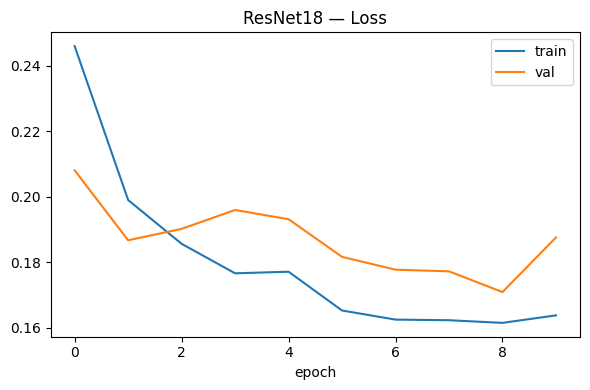

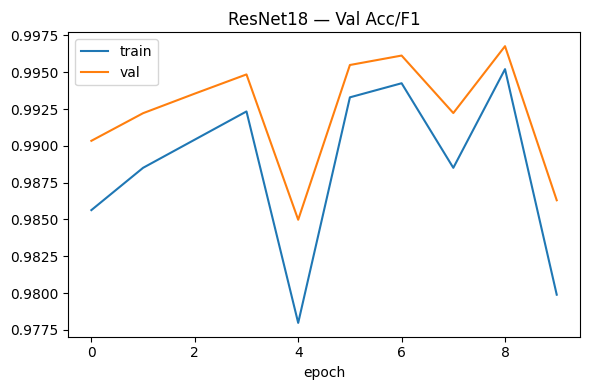

[ResNet18] chosen thr on VAL: 0.785 (VAL recall=0.978, precision=1.000)
[ResNet18 @0.5] {'acc': 0.8109, 'precision': 0.7698, 'recall': 0.9949, 'f1': 0.868, 'auroc': 0.8676, 'thr': 0.5}
[ResNet18 @Rec] {'acc': 0.8606, 'precision': 0.823, 'recall': 0.9897, 'f1': 0.8987, 'auroc': 0.8676, 'thr': 0.7847}


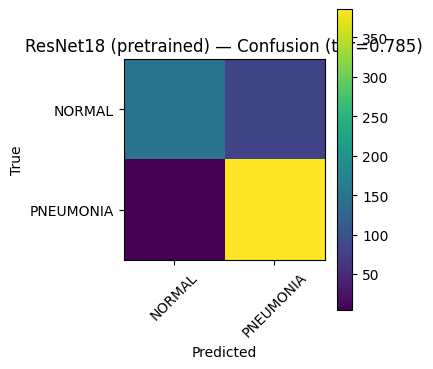

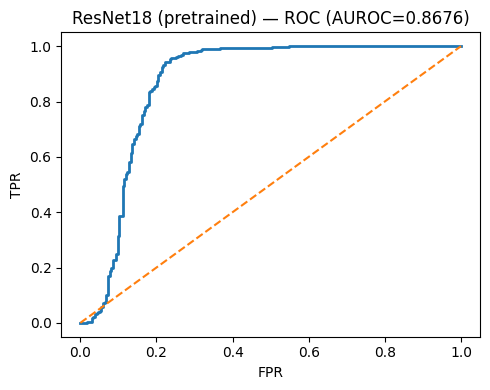

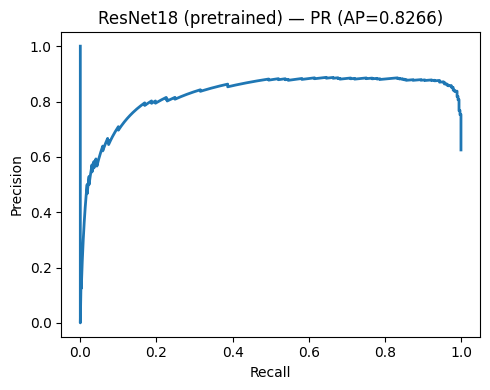

In [12]:

# %% [code] {"id":"exp_resnet18"}
# ===== EXPERIMENT B: ResNet18 (pretrained) =====
resnet = build_resnet18(num_classes=2, pretrained=True).to(DEVICE)

cw = None
if cfg.use_class_weights:
    arr = np.array(train_counts, dtype=float)
    cw_vals = arr.sum() / (len(arr) * (arr + 1e-9))
    cw = torch.tensor(cw_vals, dtype=torch.float32)

resnet, hist_rn, time_rn = train_model(
    resnet, train_loader, val_loader, DEVICE,
    epochs=cfg.resnet_epochs, base_lr=cfg.resnet_lr, weight_decay=cfg.resnet_wd,
    class_weights=cw, monitor=cfg.monitor, patience=cfg.patience, tag="resnet18_pretrained"
)

plot_curve(hist_rn["tr_loss"], hist_rn["va_loss"], "ResNet18 — Loss")
plot_curve(hist_rn["va_acc"],  hist_rn["va_f1"],  "ResNet18 — Val Acc/F1")

val_eval_r = evaluate(resnet, val_loader, DEVICE)
thr_r, rec_r, prec_r, f1r = choose_threshold_by_min_recall(val_eval_r["targets"], val_eval_r["probs"][:,1], cfg.target_recall)
print(f"[ResNet18] chosen thr on VAL: {thr_r:.3f} (VAL recall={rec_r:.3f}, precision={prec_r:.3f})")

test_eval_r = evaluate(resnet, test_loader, DEVICE)
p1_test = test_eval_r["probs"][:,1]; y_test = test_eval_r["targets"]
summary_r_05   = summarize_at_threshold(y_test, p1_test, 0.5)
summary_r_reca = summarize_at_threshold(y_test, p1_test, thr_r)
print("[ResNet18 @0.5]", {k: round(v,4) for k,v in summary_r_05.items()})
print("[ResNet18 @Rec]", {k: round(v,4) for k,v in summary_r_reca.items()})

diag_plots("ResNet18 (pretrained)", test_eval_r["probs"], y_test, thr_r, auroc=test_eval_r.get("auroc"))

resnet_results = {
    "summary@0.5": summary_r_05, "summary@recall": summary_r_reca,
    "threshold": float(thr_r), "time_sec": time_rn,
    "params": sum(p.numel() for p in resnet.parameters())
}


/var/folders/78/hsq9362565qck24p_twrvs0cx236x4/T/ipykernel_59884/2400442194.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  w = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)


[vit_scratch_sam] epoch 01/15  tr_loss=0.7287  val_loss=0.6170  val_acc=0.6753  val_f1=0.7461  val_auroc=0.7745  (no_improve=0)
[vit_scratch_sam] epoch 02/15  tr_loss=0.6625  val_loss=0.6465  val_acc=0.6858  val_f1=0.7538  val_auroc=0.7966  (no_improve=0)
[vit_scratch_sam] epoch 03/15  tr_loss=0.6045  val_loss=0.5984  val_acc=0.6475  val_f1=0.7037  val_auroc=0.8132  (no_improve=0)
[vit_scratch_sam] epoch 04/15  tr_loss=0.5706  val_loss=0.5851  val_acc=0.7481  val_f1=0.8177  val_auroc=0.8266  (no_improve=0)
[vit_scratch_sam] epoch 05/15  tr_loss=0.5569  val_loss=0.5472  val_acc=0.7807  val_f1=0.8462  val_auroc=0.8390  (no_improve=0)
[vit_scratch_sam] epoch 06/15  tr_loss=0.5500  val_loss=0.5489  val_acc=0.7787  val_f1=0.8421  val_auroc=0.8360  (no_improve=1)
[vit_scratch_sam] epoch 07/15  tr_loss=0.5355  val_loss=0.5606  val_acc=0.7222  val_f1=0.7845  val_auroc=0.8348  (no_improve=2)
[vit_scratch_sam] epoch 08/15  tr_loss=0.5219  val_loss=0.5367  val_acc=0.7126  val_f1=0.7699  val_auroc

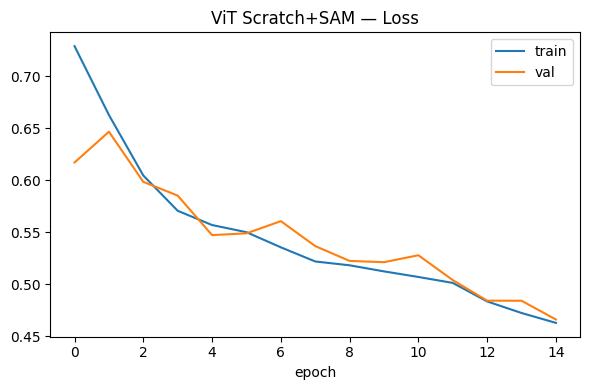

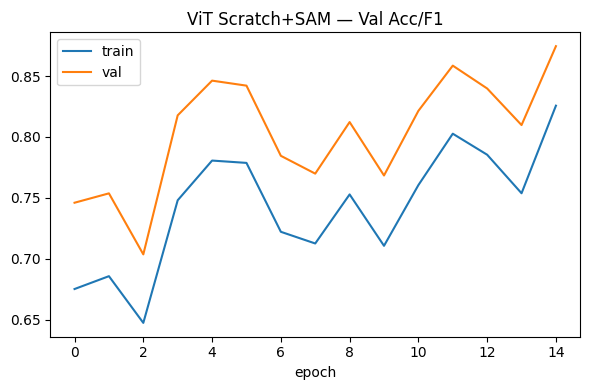

[ViT Scratch+SAM] chosen thr on VAL: 0.252 (VAL recall=0.954, precision=0.854)
[ViT Scratch+SAM @0.5] {'acc': 0.7228, 'precision': 0.7541, 'recall': 0.8256, 'f1': 0.7882, 'auroc': 0.8281, 'thr': 0.5}
[ViT Scratch+SAM @Rec] {'acc': 0.7115, 'precision': 0.6895, 'recall': 0.9795, 'f1': 0.8093, 'auroc': 0.8281, 'thr': 0.2516}


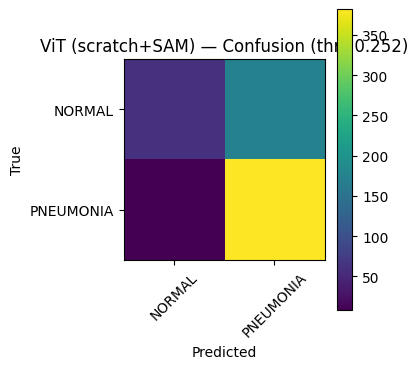

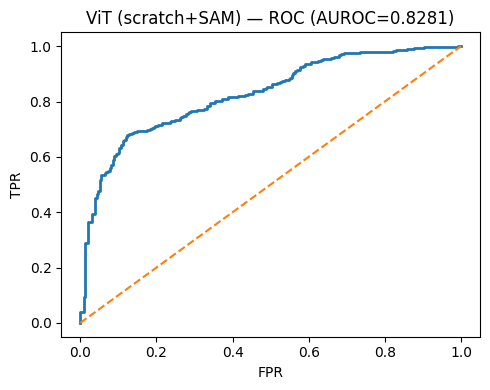

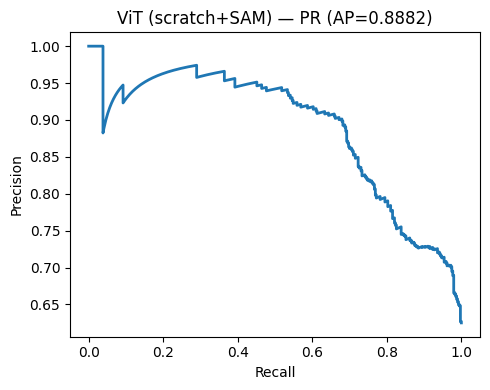

In [13]:

# %% [code] {"id":"exp_vit_scratch"}
# ===== EXPERIMENT C: ViT (from scratch) + SAM =====
vit_s = VisionTransformer(
    img_size=cfg.image_size, patch_size=cfg.patch_size, in_chans=cfg.in_channels, num_classes=2,
    embed_dim=cfg.embed_dim, depth=cfg.depth, num_heads=cfg.num_heads,
    mlp_ratio=cfg.mlp_ratio, drop_rate=cfg.drop_rate
).to(DEVICE)

cw = None
if cfg.use_class_weights:
    arr = np.array(train_counts, dtype=float)
    cw_vals = arr.sum() / (len(arr) * (arr + 1e-9))
    cw = torch.tensor(cw_vals, dtype=torch.float32)

# Use SAM per the paper; rho tuned larger for ViTs; small here for data regime (can try 0.2 - 0.3)
vit_s, hist_vits, time_vits = train_model(
    vit_s, train_loader, val_loader, DEVICE,
    epochs=cfg.cnn_epochs, base_lr=cfg.cnn_lr, weight_decay=cfg.cnn_wd,
    class_weights=cw, monitor=cfg.monitor, patience=cfg.patience, tag="vit_scratch_sam",
    use_sam=True, sam_rho=0.2
)

plot_curve(hist_vits["tr_loss"], hist_vits["va_loss"], "ViT Scratch+SAM — Loss")
plot_curve(hist_vits["va_acc"],  hist_vits["va_f1"],  "ViT Scratch+SAM — Val Acc/F1")

val_eval_vs = evaluate(vit_s, val_loader, DEVICE)
thr_vs, rec_vs, prec_vs, f1vs = choose_threshold_by_min_recall(val_eval_vs["targets"], val_eval_vs["probs"][:,1], cfg.target_recall)
print(f"[ViT Scratch+SAM] chosen thr on VAL: {thr_vs:.3f} (VAL recall={rec_vs:.3f}, precision={prec_vs:.3f})")

test_eval_vs = evaluate(vit_s, test_loader, DEVICE)
p1_test = test_eval_vs["probs"][:,1]; y_test = test_eval_vs["targets"]
summary_vs_05   = summarize_at_threshold(y_test, p1_test, 0.5)
summary_vs_reca = summarize_at_threshold(y_test, p1_test, thr_vs)
print("[ViT Scratch+SAM @0.5]", {k: round(v,4) for k,v in summary_vs_05.items()})
print("[ViT Scratch+SAM @Rec]", {k: round(v,4) for k,v in summary_vs_reca.items()})

diag_plots("ViT (scratch+SAM)", test_eval_vs["probs"], y_test, thr_vs, auroc=test_eval_vs.get("auroc"))

vit_scratch_results = {
    "summary@0.5": summary_vs_05, "summary@recall": summary_vs_reca,
    "threshold": float(thr_vs), "time_sec": time_vits,
    "params": sum(p.numel() for p in vit_s.parameters())
}


Loaded Google ViT-B/16 .npz weights.


/var/folders/78/hsq9362565qck24p_twrvs0cx236x4/T/ipykernel_59884/2400442194.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  w = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)


[vit_google_npz_pretrained_sam] epoch 01/10  tr_loss=0.3580  val_loss=0.2279  val_acc=0.9607  val_f1=0.9729  val_auroc=0.9955  (no_improve=0)
[vit_google_npz_pretrained_sam] epoch 02/10  tr_loss=0.2216  val_loss=0.2197  val_acc=0.9511  val_f1=0.9661  val_auroc=0.9970  (no_improve=0)
[vit_google_npz_pretrained_sam] epoch 03/10  tr_loss=0.1976  val_loss=0.1960  val_acc=0.9818  val_f1=0.9876  val_auroc=0.9970  (no_improve=1)
[vit_google_npz_pretrained_sam] epoch 04/10  tr_loss=0.1796  val_loss=0.1906  val_acc=0.9722  val_f1=0.9810  val_auroc=0.9993  (no_improve=0)
[vit_google_npz_pretrained_sam] epoch 05/10  tr_loss=0.1787  val_loss=0.1949  val_acc=0.9713  val_f1=0.9803  val_auroc=0.9988  (no_improve=1)
[vit_google_npz_pretrained_sam] epoch 06/10  tr_loss=0.1698  val_loss=0.1781  val_acc=0.9866  val_f1=0.9909  val_auroc=0.9995  (no_improve=0)
[vit_google_npz_pretrained_sam] epoch 07/10  tr_loss=0.1690  val_loss=0.1914  val_acc=0.9770  val_f1=0.9843  val_auroc=0.9958  (no_improve=1)
[vit_g

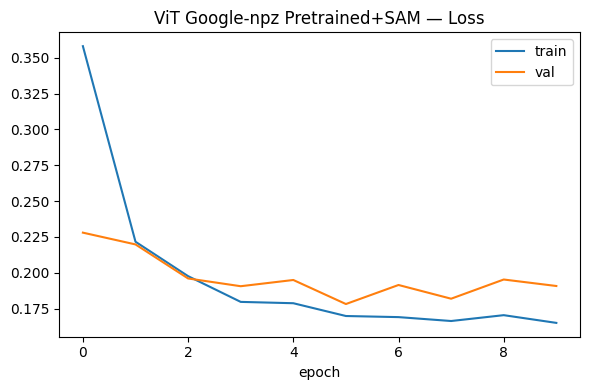

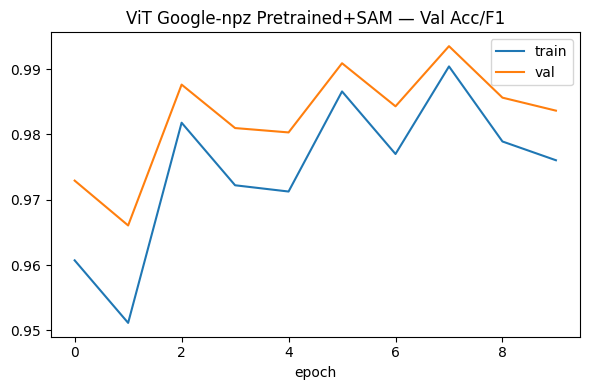

[ViT Pretrained+SAM] chosen thr on VAL: 0.261 (VAL recall=0.991, precision=0.999)
[ViT Pretrained+SAM @0.5] {'acc': 0.8029, 'precision': 0.7613, 'recall': 0.9974, 'f1': 0.8635, 'auroc': 0.9093, 'thr': 0.5}
[ViT Pretrained+SAM @Rec] {'acc': 0.7468, 'precision': 0.7125, 'recall': 0.9974, 'f1': 0.8312, 'auroc': 0.9093, 'thr': 0.261}


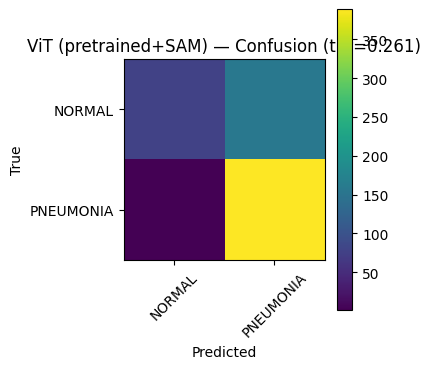

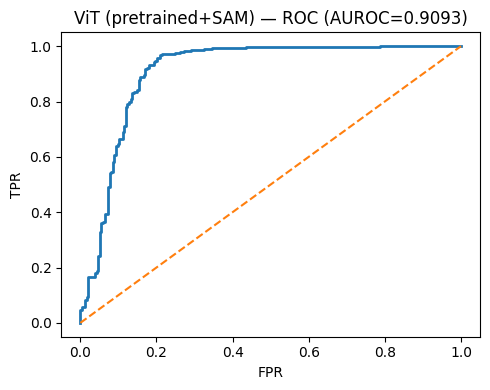

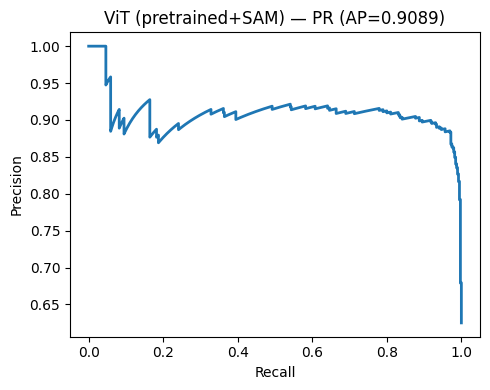

In [27]:

# %% [code] {"id":"exp_vit_pretrained"}
# ===== EXPERIMENT D: ViT-B/16 (Google .npz) + SAM =====
vit_b16 = VisionTransformer(
    img_size=cfg.image_size, patch_size=16, in_chans=3, num_classes=2,
    embed_dim=768, depth=12, num_heads=12, mlp_ratio=4.0, drop_rate=0.0
).to(DEVICE)

npz_path = WEIGHTS_DIR / "ViT-B_16.npz"
if npz_path.exists():
    vit_b16 = load_vit_npz_flexible(vit_b16, npz_path)  # <-- use the NEW loader name here
    print("Loaded Google ViT-B/16 .npz weights.")
else:
    print(f"WARNING: {npz_path} not found. Training ViT-B/16 from scratch (not recommended for small data).")

    
cw = None
if cfg.use_class_weights:
    arr = np.array(train_counts, dtype=float)
    cw_vals = arr.sum() / (len(arr) * (arr + 1e-9))
    cw = torch.tensor(cw_vals, dtype=torch.float32)

vit_b16, hist_pt, time_pt = train_model(
    vit_b16, train_loader, val_loader, DEVICE,
    epochs=cfg.pretrained_epochs, base_lr=cfg.pretrained_lr, weight_decay=cfg.pretrained_wd,
    class_weights=cw, monitor=cfg.monitor, patience=cfg.patience, tag="vit_google_npz_pretrained_sam",
    use_sam=True, sam_rho=0.2
)

plot_curve(hist_pt["tr_loss"], hist_pt["va_loss"], "ViT Google-npz Pretrained+SAM — Loss")
plot_curve(hist_pt["va_acc"],  hist_pt["va_f1"],  "ViT Google-npz Pretrained+SAM — Val Acc/F1")

val_eval_p = evaluate(vit_b16, val_loader, DEVICE)
thr_p, rec_p, prec_p, f1p = choose_threshold_by_min_recall(val_eval_p["targets"], val_eval_p["probs"][:,1], cfg.target_recall)
print(f"[ViT Pretrained+SAM] chosen thr on VAL: {thr_p:.3f} (VAL recall={rec_p:.3f}, precision={prec_p:.3f})")

test_eval_p = evaluate(vit_b16, test_loader, DEVICE)
p1_test = test_eval_p["probs"][:,1]; y_test = test_eval_p["targets"]
summary_p_05   = summarize_at_threshold(y_test, p1_test, 0.5)
summary_p_reca = summarize_at_threshold(y_test, p1_test, thr_p)
print("[ViT Pretrained+SAM @0.5]", {k: round(v,4) for k,v in summary_p_05.items()})
print("[ViT Pretrained+SAM @Rec]", {k: round(v,4) for k,v in summary_p_reca.items()})

diag_plots("ViT (pretrained+SAM)", test_eval_p["probs"], y_test, thr_p, auroc=test_eval_p.get("auroc"))

vit_pretrained_results = {
    "summary@0.5": summary_p_05, "summary@recall": summary_p_reca,
    "threshold": float(thr_p), "time_sec": time_pt,
    "params": sum(p.numel() for p in vit_b16.parameters())
}


In [28]:

# %% [code] {"id":"compare"}
rows = []
def add_row(name, res):
    if res is None: return
    r = res["summary@recall"]
    rows.append({
        "Model": name,
        "Params (M)": round(res["params"]/1e6, 2),
        "Time (min)": round(res["time_sec"]/60.0, 2),
        "Acc": round(r["acc"], 4),
        "Prec": round(r["precision"], 4),
        "Recall": round(r["recall"], 4),
        "F1": round(r["f1"], 4),
        "AUROC": round(r["auroc"], 4),
        "Thr": round(res["threshold"], 3)
    })

add_row("CNN (scratch)", cnn_results)
add_row("ResNet18 (pretrained)", resnet_results)
add_row("ViT (scratch+SAM)", vit_scratch_results)
add_row("ViT-B/16 (pretrained+SAM)", vit_pretrained_results)

df = pd.DataFrame(rows)
df


,Model,Params (M),Time (min),Acc,Prec,Recall,F1,AUROC,Thr
0,CNN (scratch),0.39,15.88,0.8462,0.8088,0.9872,0.8891,0.9207,0.365
1,ResNet18 (pretrained),11.18,12.93,0.8606,0.8230,0.9897,0.8987,0.8676,0.785
2,ViT (scratch+SAM),4.99,27.60,0.7115,0.6895,0.9795,0.8093,0.8281,0.252
3,ViT-B/16 (pretrained+SAM),85.80,72.21,0.7468,0.7125,0.9974,0.8312,0.9093,0.261


In [ ]:

# %% [code] {"id":"save"}
out_csv = Path("results_summary.csv")
df.to_csv(out_csv, index=False)
print("Saved:", out_csv.resolve())



## Why SAM & DropPath for ViT (and light aug only)?

- The ICLR 2022 paper reports ViTs and MLP‑Mixers converge to **very sharp minima** and generalize worse than ResNets when trained from scratch with only Inception‑style preprocessing; their largest Hessian eigenvalues are much bigger than ResNets’ (Table 1; Fig. 1) and training is sensitive to hparams. A **sharpness‑aware optimizer (SAM)** smooths the loss geometry and substantially improves accuracy and robustness — e.g., **+5.3% top‑1 for ViT‑B/16** on ImageNet with simple preprocessing (Table 2).  
- SAM updates weights toward solutions whose **neighborhood** has low loss by solving a small inner maximization and then taking a descent step at the perturbed point (Eq. 1–2).  
- Gains are larger for architectures **with fewer convolutional inductive biases** (ViT/Mixer) and **with longer patch sequences/larger capacity**, matching our choice to apply SAM to ViTs in this notebook.  
- We also include **DropPath (stochastic depth)** in each Transformer block’s residual branch to improve regularization while preserving the ViT design.

> In our code: we provide `SAM` (rho default 0.2 for ViT) and use **light augmentations** similar to Inception‑style preprocessing (random crop/resize + horizontal flip), consistent with the paper's setup.
